<ipython-input-12-1d2109a0fdfd>:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(lambda x: 1 if x >= 1 else 0)
/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


                            antecedents                           consequents  \
0           (ALARM CLOCK BAKELIKE RED )          (ALARM CLOCK BAKELIKE GREEN)   
1          (ALARM CLOCK BAKELIKE GREEN)           (ALARM CLOCK BAKELIKE RED )   
2   (GARDENERS KNEELING PAD KEEP CALM )  (GARDENERS KNEELING PAD CUP OF TEA )   
3  (GARDENERS KNEELING PAD CUP OF TEA )   (GARDENERS KNEELING PAD KEEP CALM )   
4     (GREEN REGENCY TEACUP AND SAUCER)      (PINK REGENCY TEACUP AND SAUCER)   
5      (PINK REGENCY TEACUP AND SAUCER)     (GREEN REGENCY TEACUP AND SAUCER)   
6     (GREEN REGENCY TEACUP AND SAUCER)    (ROSES REGENCY TEACUP AND SAUCER )   
7    (ROSES REGENCY TEACUP AND SAUCER )     (GREEN REGENCY TEACUP AND SAUCER)   
8               (HEART OF WICKER SMALL)               (HEART OF WICKER LARGE)   
9               (HEART OF WICKER LARGE)               (HEART OF WICKER SMALL)   

    support  confidence       lift  
0  0.027269    0.598945  14.451925  
1  0.027269    0.657971  14.451925

<ipython-input-12-1d2109a0fdfd>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_counts.values, y=item_counts.index, palette="Blues_d")


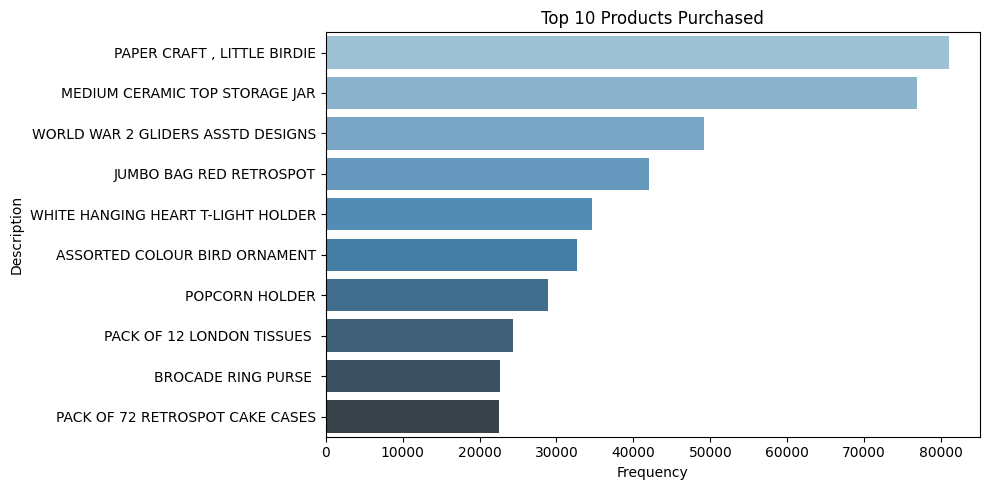

In [12]:
# Association Rule Mining - Retail Optimization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

# Load dataset
df = pd.read_csv('online-retail-dataset.csv')
df.dropna(subset=['CustomerID'], inplace=True)
df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Focus on UK
basket = (df[df['Country'] == "United Kingdom"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().fillna(0))

# Convert to binary
basket_sets = basket.applymap(lambda x: 1 if x >= 1 else 0)

# Apply Apriori
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Show top rules
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# Visualization: Top Products
item_counts = basket.sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=item_counts.values, y=item_counts.index, palette="Blues_d")
plt.title("Top 10 Products Purchased")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()